# 06 -- Provision and Utilisation Classification (O2)

Implements the classification in draft methodology 3.3.2 ("Finally, household vehicle-stock
demand is compared spatially with the existing provision from Phase 1, and categorised into
four types"), using purely descriptive category labels (no interpretive framing -- that is left
for the Discussion chapter):

$$
\text{Category}_i = \begin{cases}
\text{High vehicle stock / no registered provision}, & e_i = 0,\ H_iC_i \ge \widetilde{H_iC_i} \\
\text{Low vehicle stock / no registered provision}, & e_i = 0,\ H_iC_i < \widetilde{H_iC_i} \\
\text{Existing provision / higher observed utilisation}, & e_i > 0,\ \bar u_i \ge \widetilde{\bar u_i}^{(e>0)} \\
\text{Existing provision / lower observed utilisation}, & e_i > 0,\ \bar u_i < \widetilde{\bar u_i}^{(e>0)}
\end{cases}
$$

**Classification variable is $H_iC_i$ (raw household vehicle stock), not $B_i$ or $D_A$** --
those are already scaled by $P_d$, $P_{pub}$ and, critically, $U_i$. For LSOAs with $e_i=0$
(the ones actually being split by this threshold) $U_i$ is always the neutral value 1, so using
$B_i$ would not change the *ranking within that subset* -- but $\widetilde{H_iC_i}$ is the
median across **all** 4,994 LSOAs, most of which have $e_i>0$ and a $U_i$ that varies with
observed utilisation. Using $B_i$ for that global median would silently pull the threshold in a
direction driven by utilisation pressure elsewhere in London, not by vehicle-stock demand -- the
opposite of the draft's stated intent that "the diagnosis remained independent of the subsequent
$\alpha$ scenarios" (and, by the same logic, independent of $U_i$).

Standalone: only needs `demand_london.csv` (from 04) and the LSOA boundary shapefile. Does not
depend on 05 -- can run before, during, or after the p-median model. Figures are saved to
`06_outputs/figures`.

## 0. Setup and load data

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

BASE = "/Users/alexia/Documents/CASA/Dissertation"
OUTPUT_DIR = os.path.join(BASE, "05_processed")
FIGURES_DIR = os.path.join(BASE, "06_outputs/figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

demand = pd.read_csv(os.path.join(OUTPUT_DIR, "demand_london.csv"))
print("demand_london.csv:", demand.shape, "| columns:", list(demand.columns))
assert len(demand) == 4_994, f"Expected 4,994 London LSOAs, got {len(demand)}"

# Column names differ slightly between the Claude and GPT versions of 04 -- detect both.
UTIL_COL_CANDIDATES = ["u_i", "ubar_i"]
util_col = next((c for c in UTIL_COL_CANDIDATES if c in demand.columns), None)
if util_col is None:
    raise KeyError(f"None of {UTIL_COL_CANDIDATES} found in demand_london.csv -- "
                    f"available columns: {list(demand.columns)}")

# Classification threshold must use raw household vehicle stock (H_i x C_i), NOT B_i/D_A
# (which are already scaled by Pd, Ppub and Ui) -- see markdown cell above for why this matters.
VEHICLE_STOCK_COL_CANDIDATES = ["V_i", "HiCi"]
vehicle_stock_col = next((c for c in VEHICLE_STOCK_COL_CANDIDATES if c in demand.columns), None)
if vehicle_stock_col is None:
    raise KeyError(f"None of {VEHICLE_STOCK_COL_CANDIDATES} found in demand_london.csv -- "
                    f"available columns: {list(demand.columns)}")

DECILE_COL = "london_income_decile" if "london_income_decile" in demand.columns else "income_decile"

print(f"\nUsing utilisation column: '{util_col}'")
print(f"Using household vehicle-stock column: '{vehicle_stock_col}'")
print(f"Using deprivation decile column: '{DECILE_COL}'")

required = ["lsoa_code", "e_i", vehicle_stock_col, DECILE_COL]
missing = [c for c in required if c not in demand.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

demand_london.csv: (4994, 19) | columns: ['lsoa_code', 'lsoa_name', 'Hi', 'Ci', 'V_i', 'e_i', 'u_i', 'U_i', 'S_eff_i', 'has_evse_i', 'IMD_i', 'income_rank', 'income_decile', 'london_income_decile', 'B_i', 'D_A', 'D_B', 'D_C', 'D_D']

Using utilisation column: 'u_i'
Using household vehicle-stock column: 'V_i'
Using deprivation decile column: 'london_income_decile'


## 1. Classify each LSOA

Two-step split: first by whether provision exists ($e_i$), then by household vehicle stock (for
the no-provision branch) or utilisation (for the has-provision branch), each against a median
computed from the appropriate reference group.

In [2]:
has_provision = demand["e_i"] > 0

V_median_all = demand[vehicle_stock_col].median()
ubar_median_provided = demand.loc[has_provision, util_col].median()

print(f"London-wide median {vehicle_stock_col} (all LSOAs): {V_median_all:,.2f}")
print(f"Median {util_col} among LSOAs WITH provision only: {ubar_median_provided:.4f}")


def classify(row):
    if row["e_i"] == 0:
        if row[vehicle_stock_col] >= V_median_all:
            return "High vehicle stock / no registered provision"
        else:
            return "Low vehicle stock / no registered provision"
    else:
        if row[util_col] >= ubar_median_provided:
            return "Existing provision / higher observed utilisation"
        else:
            return "Existing provision / lower observed utilisation"


demand["mismatch_category"] = demand.apply(classify, axis=1)

category_order = [
    "High vehicle stock / no registered provision",
    "Low vehicle stock / no registered provision",
    "Existing provision / higher observed utilisation",
    "Existing provision / lower observed utilisation",
]
demand["mismatch_category"] = pd.Categorical(
    demand["mismatch_category"], categories=category_order, ordered=True
)

assert demand["mismatch_category"].isna().sum() == 0, "Every LSOA must receive a category."
assert demand["mismatch_category"].value_counts().sum() == len(demand)

print("\nCategory counts:")
print(demand["mismatch_category"].value_counts().reindex(category_order))
print("\nCategory shares:")
print((demand["mismatch_category"].value_counts(normalize=True)
       .reindex(category_order) * 100).round(1).astype(str) + "%")

London-wide median V_i (all LSOAs): 535.00
Median u_i among LSOAs WITH provision only: 0.0162

Category counts:
mismatch_category
High vehicle stock / no registered provision        1294
Low vehicle stock / no registered provision          543
Existing provision / higher observed utilisation    1579
Existing provision / lower observed utilisation     1578
Name: count, dtype: int64

Category shares:
mismatch_category
High vehicle stock / no registered provision        25.9%
Low vehicle stock / no registered provision         10.9%
Existing provision / higher observed utilisation    31.6%
Existing provision / lower observed utilisation     31.6%
Name: proportion, dtype: str


## 2. Cross-tabulate against income deprivation deciles

This is the step that actually connects O2 to the dissertation's equity narrative -- not just
"where is the mismatch" but "is the mismatch concentrated in more deprived LSOAs".

In [3]:
decile_crosstab = pd.crosstab(
    demand[DECILE_COL], demand["mismatch_category"], normalize="index"
)[category_order] * 100

print("Row-normalised (%), each row sums to 100:")
print(decile_crosstab.round(1))

high_stock_no_provision_by_decile = decile_crosstab["High vehicle stock / no registered provision"]
higher_util_by_decile = decile_crosstab["Existing provision / higher observed utilisation"]
print(f"\n'High vehicle stock / no registered provision' share, most deprived decile (1): {high_stock_no_provision_by_decile.loc[1]:.1f}%")
print(f"'High vehicle stock / no registered provision' share, least deprived decile (10): {high_stock_no_provision_by_decile.loc[10]:.1f}%")
print(f"'Existing provision / higher observed utilisation' share, most deprived decile (1): {higher_util_by_decile.loc[1]:.1f}%")
print(f"'Existing provision / higher observed utilisation' share, least deprived decile (10): {higher_util_by_decile.loc[10]:.1f}%")

Row-normalised (%), each row sums to 100:
mismatch_category     High vehicle stock / no registered provision  \
london_income_decile                                                 
1                                                             10.6   
2                                                             19.4   
3                                                             21.8   
4                                                             24.2   
5                                                             27.9   
6                                                             25.1   
7                                                             27.8   
8                                                             30.1   
9                                                             34.1   
10                                                            38.2   

mismatch_category     Low vehicle stock / no registered provision  \
london_income_decile                            

## 3. Figure -- Panel A: classification map, Panel B: decile distribution

Panel A uses a two-hue, two-shade discrete scheme: orange for the two no-provision categories
(dark = high vehicle stock, light = low vehicle stock) and blue for the two has-provision
categories (dark = higher observed utilisation, light = lower observed utilisation). Colour
encodes only the classification structure -- which branch of the tree, and which side of the
threshold within it -- rather than implying which categories are "problems"; that judgement is
left for the Discussion chapter.

LSOA boundaries matched: 4994 / 4994 expected


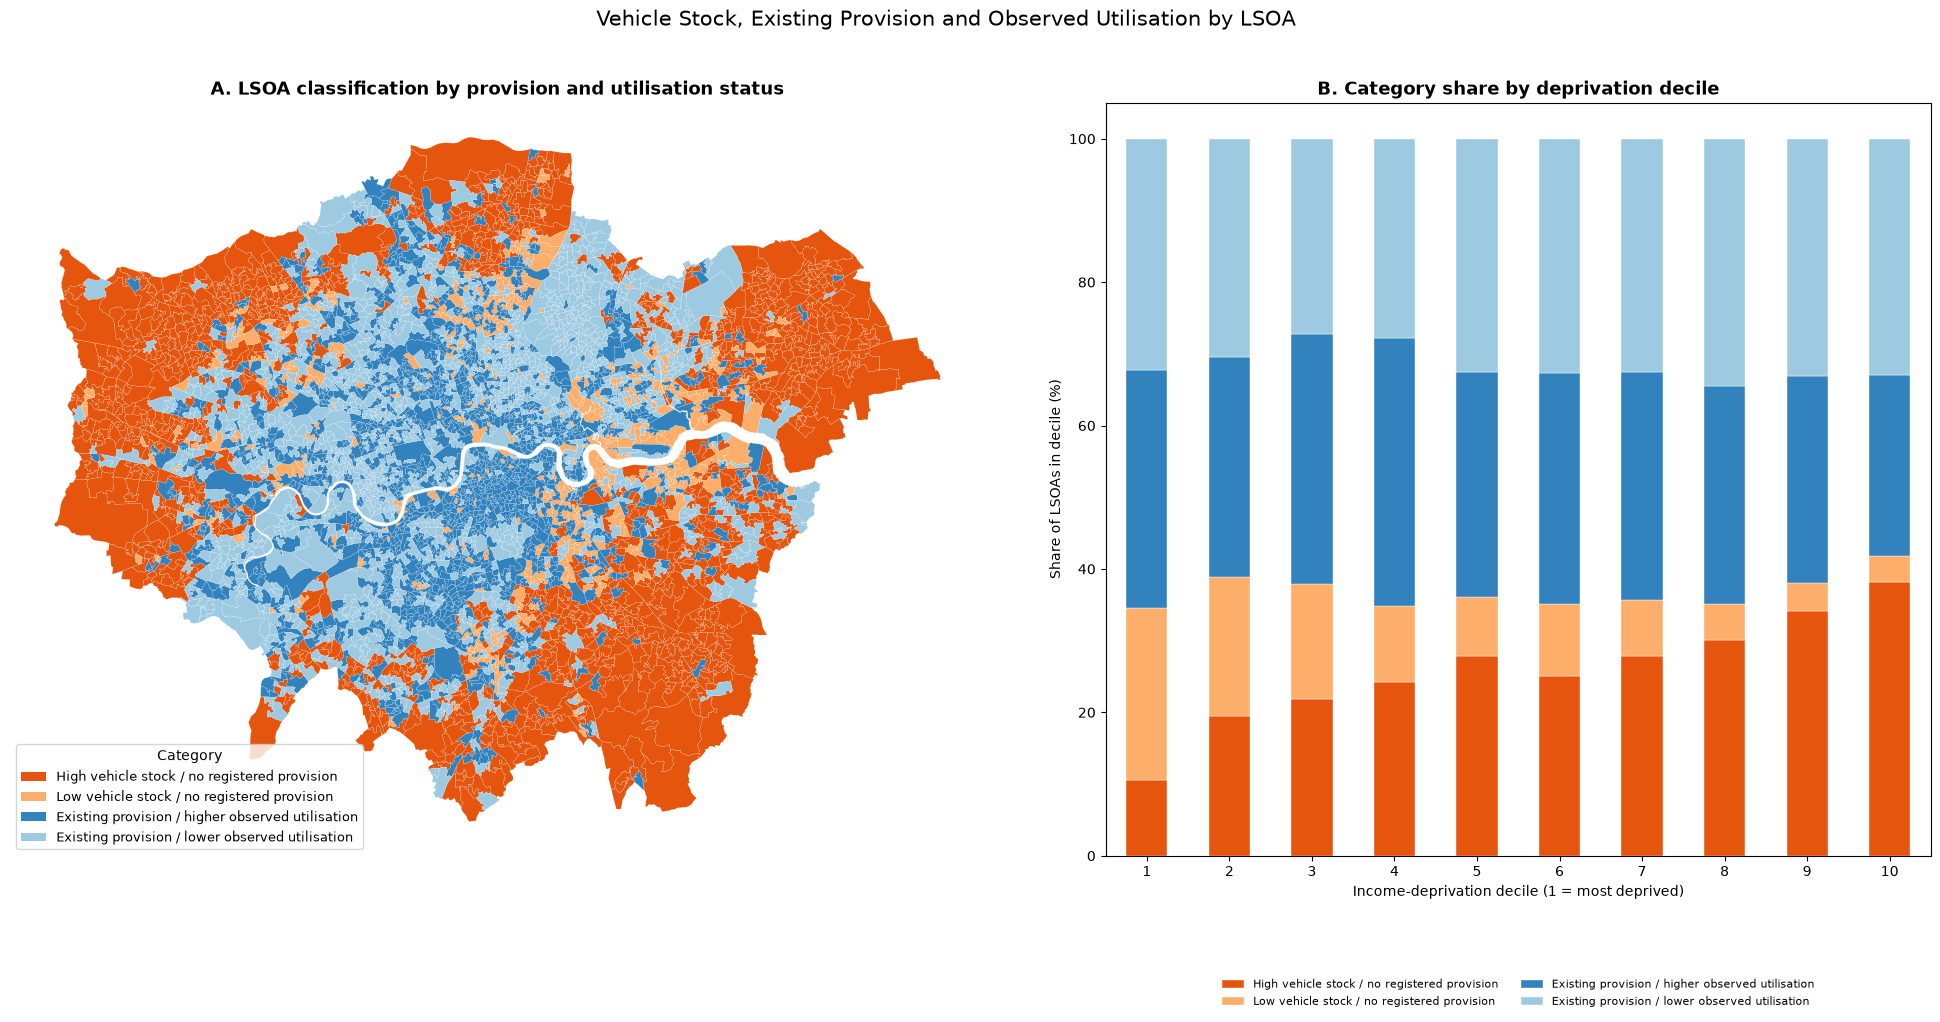

In [4]:
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(demand["lsoa_code"])].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]
print(f"LSOA boundaries matched: {len(lsoa_london)} / {len(demand)} expected")

category_colors = {
    "High vehicle stock / no registered provision": "#e6550d",     # dark orange
    "Low vehicle stock / no registered provision":  "#fdae6b",     # light orange
    "Existing provision / higher observed utilisation": "#3182bd", # dark blue
    "Existing provision / lower observed utilisation":  "#9ecae1", # light blue
}

map_data = lsoa_london.merge(
    demand[["lsoa_code", "mismatch_category"]], on="lsoa_code", how="left"
)

fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(20, 10), gridspec_kw={"width_ratios": [1.3, 1]})

for category in category_order:
    subset = map_data.loc[map_data["mismatch_category"] == category]
    subset.plot(ax=ax_map, color=category_colors[category], edgecolor="white", linewidth=0.1)

legend_handles = [Patch(facecolor=category_colors[c], edgecolor="none", label=c)
                  for c in category_order]
ax_map.legend(handles=legend_handles, loc="lower left", fontsize=9, frameon=True,
              title="Category")
ax_map.set_title("A. LSOA classification by provision and utilisation status", fontsize=13, fontweight="bold")
ax_map.axis("off")

decile_crosstab.loc[range(1, 11), category_order].plot(
    kind="bar", stacked=True, ax=ax_bar,
    color=[category_colors[c] for c in category_order],
    edgecolor="white", linewidth=0.3,
)
ax_bar.set_xlabel("Income-deprivation decile (1 = most deprived)")
ax_bar.set_ylabel("Share of LSOAs in decile (%)")
ax_bar.set_title("B. Category share by deprivation decile", fontsize=13, fontweight="bold")
ax_bar.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=8, frameon=False)
ax_bar.set_xticklabels(range(1, 11), rotation=0)

plt.suptitle("Vehicle Stock, Existing Provision and Observed Utilisation by LSOA",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_provision_utilisation_typology.png"), dpi=300, bbox_inches="tight")
plt.show()

LSOA boundaries matched: 4994 / 4994 expected


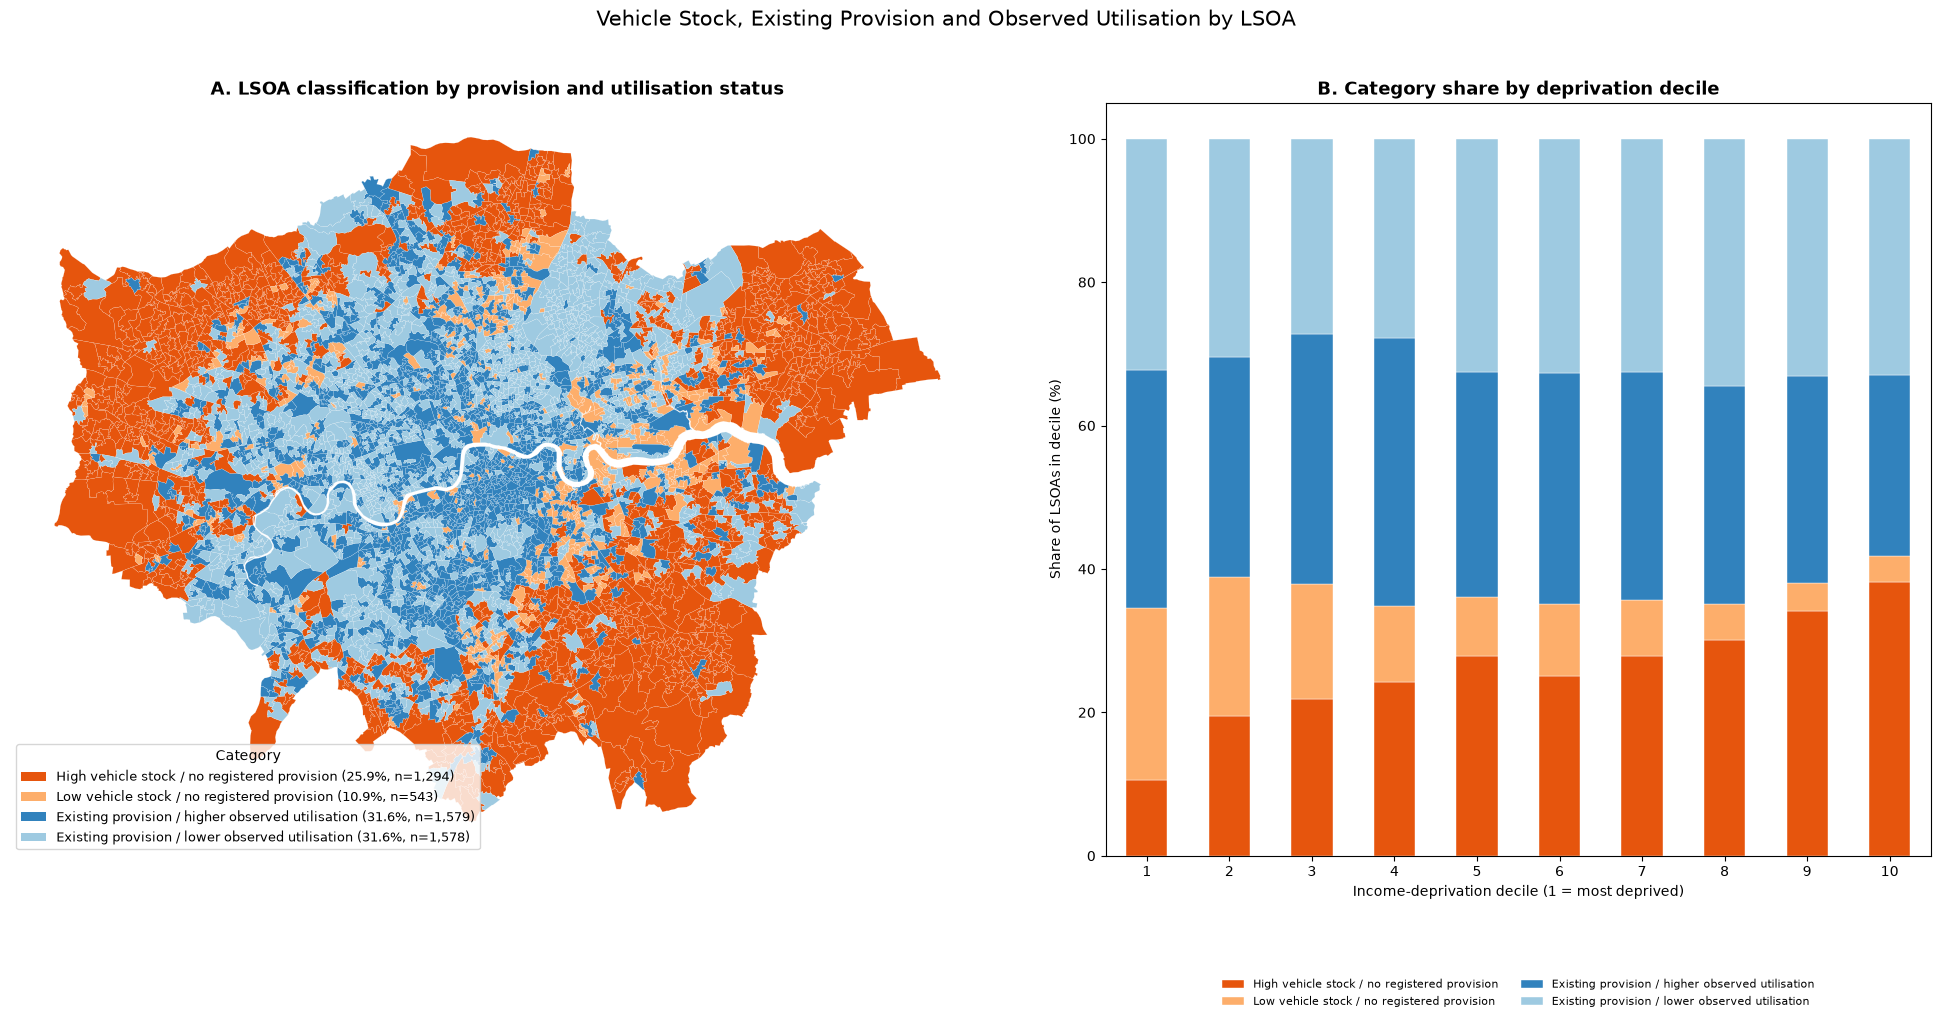

In [7]:
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(demand["lsoa_code"])].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]
print(f"LSOA boundaries matched: {len(lsoa_london)} / {len(demand)} expected")

category_colors = {
    "High vehicle stock / no registered provision": "#e6550d",     # dark orange
    "Low vehicle stock / no registered provision":  "#fdae6b",     # light orange
    "Existing provision / higher observed utilisation": "#3182bd", # dark blue
    "Existing provision / lower observed utilisation":  "#9ecae1", # light blue
}

map_data = lsoa_london.merge(
    demand[["lsoa_code", "mismatch_category"]], on="lsoa_code", how="left"
)

fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(20, 10), gridspec_kw={"width_ratios": [1.3, 1]})

for category in category_order:
    subset = map_data.loc[map_data["mismatch_category"] == category]
    subset.plot(ax=ax_map, color=category_colors[category], edgecolor="white", linewidth=0.1)

# --- NEW: compute counts and shares for the legend ---
category_counts = demand["mismatch_category"].value_counts().reindex(category_order)
category_shares = (category_counts / len(demand) * 100).round(1)

legend_handles = [
    Patch(facecolor=category_colors[c], edgecolor="none",
          label=f"{c} ({category_shares[c]:.1f}%, n={category_counts[c]:,})")
    for c in category_order
]
# --- end NEW ---

ax_map.legend(handles=legend_handles, loc="lower left", fontsize=9, frameon=True,
              title="Category")
ax_map.set_title("A. LSOA classification by provision and utilisation status", fontsize=13, fontweight="bold")
ax_map.axis("off")

decile_crosstab.loc[range(1, 11), category_order].plot(
    kind="bar", stacked=True, ax=ax_bar,
    color=[category_colors[c] for c in category_order],
    edgecolor="white", linewidth=0.3,
)
ax_bar.set_xlabel("Income-deprivation decile (1 = most deprived)")
ax_bar.set_ylabel("Share of LSOAs in decile (%)")
ax_bar.set_title("B. Category share by deprivation decile", fontsize=13, fontweight="bold")
ax_bar.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=8, frameon=False)
ax_bar.set_xticklabels(range(1, 11), rotation=0)

plt.suptitle("Vehicle Stock, Existing Provision and Observed Utilisation by LSOA",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_provision_utilisation_typology.png"), dpi=300, bbox_inches="tight")
plt.show()

## 4. Save outputs

In [5]:
output_cols = ["lsoa_code", "e_i", util_col, vehicle_stock_col, DECILE_COL, "mismatch_category"]
mismatch_output = demand[output_cols].copy()

output_path = os.path.join(OUTPUT_DIR, "mismatch_diagnostic.csv")
mismatch_output.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

decile_crosstab.to_csv(os.path.join(OUTPUT_DIR, "mismatch_by_decile.csv"))
print(f"Saved: {os.path.join(OUTPUT_DIR, 'mismatch_by_decile.csv')}")

mismatch_output.head()

Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/mismatch_diagnostic.csv
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/mismatch_by_decile.csv


,lsoa_code,e_i,u_i,V_i,london_income_decile,mismatch_category
0,E01000001,1,0.243911,331.0,10,Existing provision / higher observed utilisation
1,E01000002,1,0.015972,296.0,10,Existing provision / lower observed utilisation
2,E01000003,0,NaN,220.0,9,Low vehicle stock / no registered provision
3,E01000005,0,NaN,119.0,7,Low vehicle stock / no registered provision
4,E01000006,0,NaN,516.0,4,Low vehicle stock / no registered provision


## 5. Update pipeline_summary.csv

In [6]:
pipeline_summary_path = os.path.join(OUTPUT_DIR, "pipeline_summary.csv")
pipeline_summary = pd.read_csv(pipeline_summary_path)

new_row = {"output": "mismatch_diagnostic.csv", "rows": len(mismatch_output),
           "observation_unit": "LSOA"}
if (pipeline_summary["output"] == new_row["output"]).any():
    pipeline_summary.loc[pipeline_summary["output"] == new_row["output"],
                          ["rows", "observation_unit"]] = [new_row["rows"], new_row["observation_unit"]]
else:
    pipeline_summary = pd.concat([pipeline_summary, pd.DataFrame([new_row])], ignore_index=True)

pipeline_summary.to_csv(pipeline_summary_path, index=False)
print(pipeline_summary.to_string(index=False))

                        output   rows  observation_unit
       census_london_clean.csv   4994              LSOA
          imd_london_clean.csv   4994              LSOA
       evse_registry_clean.csv  38358              EVSE
         osev_london_clean.csv  23008 charging location
              zapmap_clean.csv 524116  charging session
      evse_utilisation_all.csv  38358              EVSE
location_utilisation_clean.csv  23008 charging location
       location_lsoa_clean.csv  23008 charging location
         lsoa_supply_clean.csv   4994              LSOA
     cleaning_decision_log.csv      7 cleaning decision
       mismatch_diagnostic.csv   4994              LSOA
